In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle
import os
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams["svg.fonttype"] = "none"

mpl.rcParams['font.family'] = 'Helvetica'
mpl.rc('lines', linewidth=1)
mpl.rc('font', family='Helvetica', size=8)
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=7)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=6)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)

plt.rcParams['agg.path.chunksize'] = 10000

metadata_path = './data_files/ipsc_derived_neurons_humans_metadata.csv'
metadata = pd.read_csv(metadata_path)


In [2]:
with open('./scaling_data/data_for_scaling_allGroups.pkl', 'rb') as file:
    exp_dict = pickle.load(file)


Starting to generate scaling plots for iPSC-derived neurons...
Found 9 iPSC-derived neuron samples
Metadata contains 10 entries
Available in exp_dict: 9 samples
Samples: ['Ballerino2022_iPSC_NeuNplus', 'Li2022_iPSC_NeuNplus', 'Lu2020_iPSC_NeuNplus', 'Lagarkova_culture_iPSC_NeuNplus', 'PsychENCODE_iPSC_NeuNplus', 'Wu2021_iPSC_NeuNplus', 'Zaghi2023_iPSC_NeuNplus', 'Okhovat2023_iPSC_NeuNplus_5kb', 'Titus_Neuron']

1. Plotting by Duration Groups...
Saved: scaling_ipsc_neurons_by_duration_groups.svg


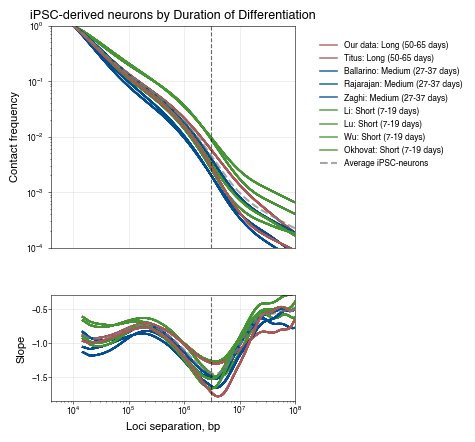


2. Plotting by General Label...
Saved: scaling_ipsc_neurons_by_general_label.svg


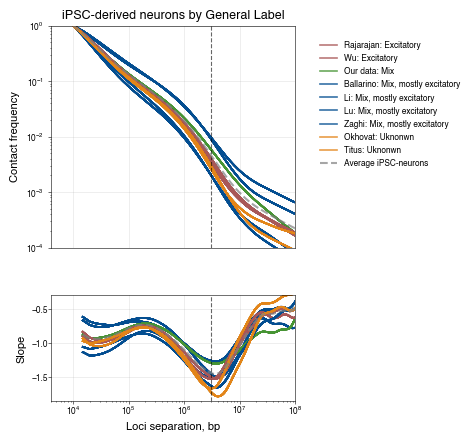


3. Plotting by Intended Subtypes...
Saved: scaling_ipsc_neurons_by_intended_subtypes.svg


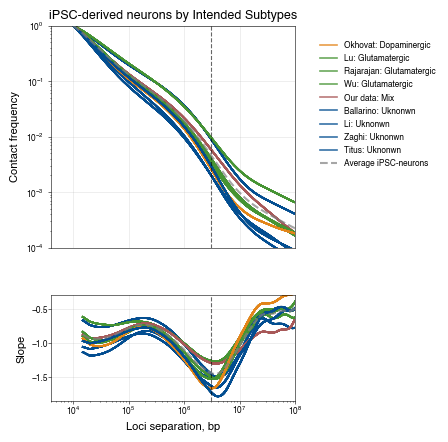


4. Plotting by Protocol Label...
Saved: scaling_ipsc_neurons_by_protocol_label.svg


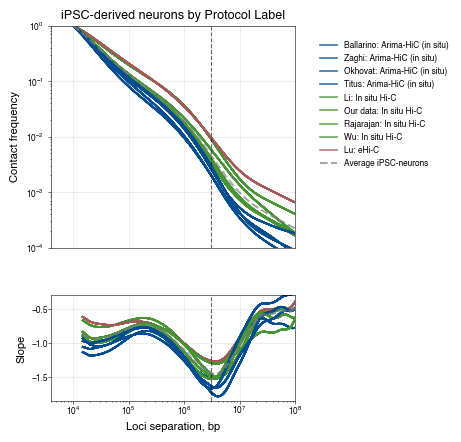


5. Plotting by Restriction Enzyme...
Saved: scaling_ipsc_neurons_by_restriction_enzyme.svg


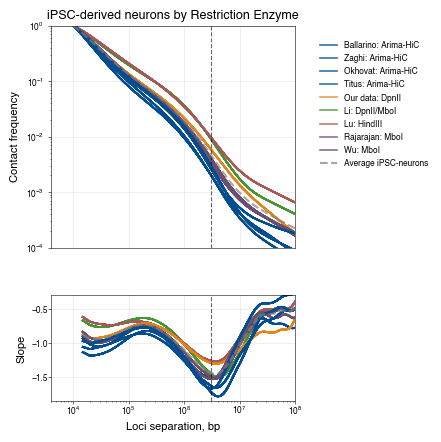


All 5 plots generated successfully!


In [27]:
plt.rcParams['agg.path.chunksize'] = 10000
ipsc_neuron_samples = [
    'Ballerino2022_iPSC_NeuNplus',
    'Li2022_iPSC_NeuNplus',
    'Lu2020_iPSC_NeuNplus',  
    'Lagarkova_culture_iPSC_NeuNplus',
    'PsychENCODE_iPSC_NeuNplus',  
    'Wu2021_iPSC_NeuNplus',
    'Zaghi2023_iPSC_NeuNplus',
    'Okhovat2023_iPSC_NeuNplus_5kb',
    'Titus_Neuron'
]

sample_to_author = {
    'Ballerino2022_iPSC_NeuNplus': 'Ballarino',
    'Li2022_iPSC_NeuNplus': 'Li',
    'Lu2020_iPSC_NeuNplus': 'Lu',
    'Lagarkova_culture_iPSC_NeuNplus': 'Our data',
    'PsychENCODE_iPSC_NeuNplus': 'Rajarajan',
    'Wu2021_iPSC_NeuNplus': 'Wu',
    'Zaghi2023_iPSC_NeuNplus': 'Zaghi',
    'Okhovat2023_iPSC_NeuNplus_5kb': 'Okhovat',
    'Titus_Neuron': 'Titus'
}

metadata['sample_simple'] = metadata['sample_simple'].str.strip()

def create_duration_groups(duration):
    """Create 3 discrete groups based on duration of differentiation"""
    if pd.isna(duration):
        return 'Unknown'
    duration = float(duration)
    if duration <= 19:
        return 'Short (7-19 days)'
    elif duration <= 37:
        return 'Medium (27-37 days)'
    else:
        return 'Long (50-65 days)'

metadata['Duration_Group'] = metadata['Duration of differentiation (days)'].apply(create_duration_groups)

def generate_distinct_colors(num_colors):
    """Generate scientifically appropriate, publication-quality colors"""
    # Publication-quality color palette with good separation and contrast
    publication_palette = [
        '#034e91',  # Deep blue
        '#469433',  # Green
        '#a85858',  # Rose/red
        '#e38519',  # Orange
        '#6b4e71',  # Purple
        '#6bcfcf',  # Cyan
        '#a87963',  # Brown
        '#9955a2',  # Magenta
        '#e8bc64',  # Gold
        '#5f1ea6',  # Violet
        '#1fc24a',  # Bright green
        '#d4adab',  # Dusty rose
        '#a086bd',  # Lavender
        '#967978',  # Taupe
        '#bfb2cf',  # Light purple
        '#b0e8a9',  # Light green
        '#08472b',  # Dark green
        '#696969'   # Grey
    ]
    
    return publication_palette[:num_colors]

def calculate_average_scaling(cvd_smooth_agg, samples, res=5000):
    """Calculate average scaling across all iPSC-derived neuron samples"""
    all_data = []
    
    for sample in samples:
        if sample in cvd_smooth_agg:
            df = cvd_smooth_agg[sample].copy()
            df['dist'] = pd.to_numeric(df['dist'], errors='coerce').fillna(0).astype(int)
            df['s_bp'] = df['dist'] * res
            df.loc[df['dist'] < 2, 'balanced.avg.smoothed.agg'] = np.nan
            df['balanced.avg.smoothed.agg.norm'] = \
                df['balanced.avg.smoothed.agg'] / df['balanced.avg.smoothed.agg'].values[2]
            all_data.append(df[['s_bp', 'balanced.avg.smoothed.agg.norm']])
    
    if not all_data:
        return None, None
    
    avg_df = pd.concat(all_data).groupby('s_bp').mean().reset_index()
    der = np.gradient(np.log(avg_df['balanced.avg.smoothed.agg.norm']),
                      np.log(avg_df['s_bp']))
    
    return avg_df, der

def plot_scaling_by_category(cvd_smooth_agg, metadata, category_column, 
                             category_name, res=5000, save_name=None):
    """
    Plot scaling for iPSC-derived neurons colored by a specific category
    """
    f, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios':[3, 1], 'hspace': 0.0},
                          figsize=(4.4, 5.5))
    
    unique_categories = []
    for sample in ipsc_neuron_samples:
        if sample not in cvd_smooth_agg:
            continue
        author = sample_to_author.get(sample)
        if author:
            sample_meta = metadata[metadata['sample_simple'] == author]
            if not sample_meta.empty:
                category_value = sample_meta[category_column].values[0]
                if pd.notna(category_value) and category_value != '' and category_value not in unique_categories:
                    unique_categories.append(category_value)
    
    if not unique_categories:
        unique_categories = ['Unknown']
    
    colors = generate_distinct_colors(len(unique_categories))
    color_map = dict(zip(unique_categories, colors))
    
    avg_scaling, avg_der = calculate_average_scaling(cvd_smooth_agg, ipsc_neuron_samples, res)
    
    for sample in ipsc_neuron_samples:
        if sample not in cvd_smooth_agg:
            continue
        
        author = sample_to_author.get(sample)
        category_value = 'Unknown'
        if author:
            sample_meta = metadata[metadata['sample_simple'] == author]
            if not sample_meta.empty:
                cat_val = sample_meta[category_column].values[0]
                if pd.notna(cat_val) and cat_val != '':
                    category_value = cat_val
        
        cvd_smooth_agg[sample]['dist'] = pd.to_numeric(cvd_smooth_agg[sample]['dist'], 
                                                        errors='coerce').fillna(0).astype(int)
        cvd_smooth_agg[sample]['s_bp'] = cvd_smooth_agg[sample]['dist'] * res
        cvd_smooth_agg[sample].loc[cvd_smooth_agg[sample]['dist'] < 2, 
                                   'balanced.avg.smoothed.agg'] = np.nan
        cvd_smooth_agg[sample]['balanced.avg.smoothed.agg.norm'] = \
            cvd_smooth_agg[sample]['balanced.avg.smoothed.agg'] / \
            cvd_smooth_agg[sample]['balanced.avg.smoothed.agg'].values[2]
        
        der = np.gradient(np.log(cvd_smooth_agg[sample]['balanced.avg.smoothed.agg.norm']),
                          np.log(cvd_smooth_agg[sample]['s_bp']))
        
        ax = axs[0]
        ax.loglog(
            cvd_smooth_agg[sample]['s_bp'].tolist(),
            cvd_smooth_agg[sample]['balanced.avg.smoothed.agg.norm'].tolist(),
            label=f"{author}: {category_value}",
            color=color_map.get(category_value, '#808080'),
            linewidth=1.2,
            alpha=0.8
        )
        
        ax = axs[1]
        ax.semilogx(
            cvd_smooth_agg[sample]['s_bp'].tolist(),
            der,
            color=color_map.get(category_value, '#808080'),
            linewidth=1.2,
            alpha=0.8
        )
    
    if avg_scaling is not None:
        ax = axs[0]
        ax.loglog(
            avg_scaling['s_bp'].tolist(),
            avg_scaling['balanced.avg.smoothed.agg.norm'].tolist(),
            color='grey',
            linewidth=1.5,
            linestyle='--',
            label='Average iPSC-neurons',
            alpha=0.7,
            zorder=100
        )
        
        ax = axs[1]
        ax.semilogx(
            avg_scaling['s_bp'].tolist(),
            avg_der,
            color='grey',
            linewidth=1.5,
            linestyle='--',
            alpha=0.7,
            zorder=100
        )
    
    ax = axs[0]
    ax.plot([3e6, 3e6], [1e-4, 1], 'k--', alpha=0.6, linewidth=0.8)
    ax.set(ylabel='Contact frequency')
    ax.set_xlim([4000, 1e8])
    ax.set_ylim([1e-4, 1])
    ax.set_adjustable("box")
    ax.set_aspect(1)
    ax.grid(lw=0.5, alpha=0.3)
    ax.set_title(f'iPSC-derived neurons by {category_name}', fontsize=9, pad=5)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False, pad=0)
    
    ax = axs[1]
    ax.plot([3e6, 3e6], [-1.85, -0.3], 'k--', alpha=0.6, linewidth=0.8)
    ax.set(
        xlabel='Loci separation, bp',
        ylabel='Slope',
    )
    ax.grid(lw=0.5, alpha=0.3)
    ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8], minor=False)
    ax.set_ylim([-1.85, -0.3])
    ax.tick_params(axis='x', pad=0)
    ax.tick_params(axis='y', pad=0)
    
    lines, labels = axs[0].get_legend_handles_labels()
    
    # Sort legend by category (group labels together)
    # Separate average line from category lines
    sorted_items = []
    avg_item = None
    
    for line, label in zip(lines, labels):
        if 'Average' in label:
            avg_item = (line, label)
        else:
            sorted_items.append((line, label))
    
    # Sort by category (extract category after colon)
    sorted_items.sort(key=lambda x: x[1].split(': ')[-1] if ': ' in x[1] else x[1])
    
    # Add average at the end
    if avg_item:
        sorted_items.append(avg_item)
    
    sorted_lines = [item[0] for item in sorted_items]
    sorted_labels = [item[1] for item in sorted_items]
    
    f.legend(
        sorted_lines, sorted_labels, 
        bbox_to_anchor=(0.73, 0.65), 
        loc='center left', 
        fontsize=6,
        borderaxespad=0,
        frameon=False
    )
    plt.subplots_adjust(right=0.68, hspace=0.0)
    
    if save_name:
        os.makedirs('./general_chromatin_analysis_visualizations', exist_ok=True)
        plt.savefig(f'./general_chromatin_analysis_visualizations/{save_name}.svg', 
                   bbox_inches='tight', format='svg')
        print(f"Saved: {save_name}.svg")
    
    plt.show()
    plt.close()

print("Starting to generate scaling plots for iPSC-derived neurons...")
print(f"Found {len(ipsc_neuron_samples)} iPSC-derived neuron samples")
print(f"Metadata contains {len(metadata)} entries")

available_samples = [s for s in ipsc_neuron_samples if s in exp_dict]
print(f"Available in exp_dict: {len(available_samples)} samples")
print(f"Samples: {available_samples}")

print("\n1. Plotting by Duration Groups...")
plot_scaling_by_category(exp_dict, metadata, 'Duration_Group', 
                         'Duration of Differentiation',
                         save_name='scaling_ipsc_neurons_by_duration_groups')

print("\n2. Plotting by General Label...")
plot_scaling_by_category(exp_dict, metadata, 'General label', 
                         'General Label',
                         save_name='scaling_ipsc_neurons_by_general_label')

print("\n3. Plotting by Intended Subtypes...")
plot_scaling_by_category(exp_dict, metadata, 'Intended subtypes', 
                         'Intended Subtypes',
                         save_name='scaling_ipsc_neurons_by_intended_subtypes')

print("\n4. Plotting by Protocol Label...")
plot_scaling_by_category(exp_dict, metadata, 'Protocol label', 
                         'Protocol Label',
                         save_name='scaling_ipsc_neurons_by_protocol_label')

print("\n5. Plotting by Restriction Enzyme...")
plot_scaling_by_category(exp_dict, metadata, 'Restriction Enzyme', 
                         'Restriction Enzyme',
                         save_name='scaling_ipsc_neurons_by_restriction_enzyme')

print("\nAll 5 plots generated successfully!")
